# Import libraries

In [1]:
import pandas as pd
import numpy as np
from os.path import join as pjoin
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

plt.rcParams["text.usetex"] = False
plt.rcParams["svg.fonttype"] = "none"
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams["font.size"] = 12
plt.rcParams["figure.dpi"] = 100

%config InlineBackend.figure_format = 'svg'
%matplotlib widget
%load_ext autoreload
%autoreload 2

# Load data

In [2]:
# %% Load data
animal = "GRB006"  # example animal
session = "20240821_121447"  # "20240723_142451"  # example session

data_dir = "/Users/gabriel/data"
trial_ts = pd.read_pickle(
    pjoin(data_dir, animal, session, "pre_processed", "trial_ts.pkl")
)
spike_times_per_unit = np.load(
    pjoin(data_dir, animal, session, "pre_processed", "spike_times_per_unit.npy"),
    allow_pickle=True,
)

trial_ts = trial_ts[
    trial_ts["stationary_stims"].apply(lambda x: len(x) > 0)
    & trial_ts["movement_stims"].apply(lambda x: len(x) > 0)
    & trial_ts["center_port_entries"].apply(lambda x: len(x) > 0)
].copy()

In [3]:
trial_ts

,category,trial_rate,detected_events,trial_start,stim_ts,first_stim_ts,stimulus_modality,response_side,correct_side,trial_outcome,center_port_entries,center_port_exits,left_port_entries,left_port_exits,right_port_entries,right_port_exits,stim_ts_visual,stim_ts_audio,response,stationary_stims,movement_stims
1,right,18,18,45.032700,"[63.46521276980432, 63.545262050592804, 63.625...",63.465213,visual,NaN,1,2,[63.43353333333334],[63.9852],[51.259366666666665],[51.702866666666665],[],[],"[63.46521276980432, 63.545262050592804, 63.625...",[],NaN,"[63.46521276980432, 63.545262050592804, 63.625...","[64.02517372917967, 64.06522236995792, 64.1052..."
2,boundary,12,12,74.036567,"[89.55855733333334, 89.63860533333335, 89.6786...",89.558557,visual,1.0,1,1,[89.47103333333334],[90.0619],[],[],[91.0864],[],"[89.55855733333334, 89.63860533333335, 89.6786...",[],91.086400,"[89.55855733333334, 89.63860533333335, 89.6786...","[90.11855733333334, 90.15860533333334, 90.2384..."
3,left,6,6,91.156133,"[95.46997999999999, 95.51002799999999, 95.9099...",95.469980,visual,0.0,0,1,[95.4191],[96.07383333333334],[96.92466666666667],[],[],[94.70476666666667],"[95.46997999999999, 95.51002799999999, 95.9099...",[],96.924667,"[95.46997999999999, 95.51002799999999, 95.9099...","[96.1899604512, 96.3499391184]"
4,boundary,12,11,96.998700,"[100.70418533333334, 100.86416933333334, 100.9...",100.704185,visual,0.0,1,0,[100.6796],[101.21323333333333],[101.63596666666666],"[98.72263333333333, 102.2096]",[],[],"[100.70418533333334, 100.86416933333334, 100.9...",[],101.635967,"[100.70418533333334, 100.86416933333334, 100.9...","[101.26402822285156, 101.30402886286181, 101.3..."
6,right,14,14,106.161333,"[106.82348, 106.94346399999999, 107.023464, 10...",106.823480,visual,0.0,1,0,[106.74373333333334],[107.53126666666667],"[108.09196666666666, 108.48053333333333]","[108.48053333333333, 108.4806]",[],[],"[106.82348, 106.94346399999999, 107.023464, 10...",[],108.091967,"[106.82348, 106.94346399999999, 107.023464, 10...","[107.62338199999999, 107.66338066666667, 107.7..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,boundary,12,12,3072.152833,"[3073.616822666667, 3073.736918666667, 3073.77...",3073.616823,visual,0.0,0,1,[3073.5753],[3074.1439],[3074.7429],[],[],[],"[3073.616822666667, 3073.736918666667, 3073.77...",[],3074.742900,"[3073.616822666667, 3073.736918666667, 3073.77...","[3074.3367492602665, 3074.4168425904, 3074.456..."
496,right,16,16,3127.793567,"[3132.890848, 3132.930736, 3133.010784, 3133.1...",3132.890848,visual,1.0,1,1,[3132.8246],[3133.4021666666667],[],[],[3133.8672333333334],[],"[3132.890848, 3132.930736, 3133.010784, 3133.1...",[],3133.867233,"[3132.890848, 3132.930736, 3133.010784, 3133.1...","[3133.4506747770665, 3133.5307201088003, 3133...."
499,left,8,8,3144.649067,"[3145.7081331349304, 3145.7480697739165, 3145....",3145.708133,visual,1.0,0,0,[3145.6122666666665],[3146.2286],[],[],[3146.8413],[3147.519333333333],"[3145.7081331349304, 3145.7480697739165, 3145....",[],3146.841300,"[3145.7081331349304, 3145.7480697739165, 3145....","[3146.3080181946666, 3146.4679968618666, 3146...."
500,left,10,10,3147.894400,"[3151.8542, 3151.934088, 3151.974088, 3152.054...",3151.854200,visual,1.0,0,0,[3151.7935333333335],[3152.381733333333],[],[],[3152.85],[3153.3091],"[3151.8542, 3151.934088, 3151.974088, 3152.054...",[],3152.850000,"[3151.8542, 3151.934088, 3151.974088, 3152.054...","[3152.4140457639323, 3152.4540464039424, 3152...."


In [4]:
portTimes = trial_ts["center_port_entries"].to_numpy()
display(portTimes[118])  # Displays the empty value

stimTimes = trial_ts["first_stim_ts"].to_numpy()
display(stimTimes[263] - portTimes[263][0])  # displays the 231.9 ms delay

[1114.5616666666667]

0.025758666667115904

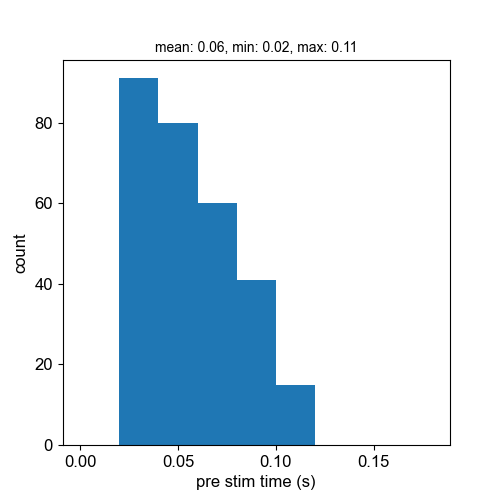

In [14]:
data = pd.DataFrame(
    {
        "center_entries": trial_ts.center_port_entries.apply(lambda x: x[0]),
        "first_stim": trial_ts.first_stim_ts,
        "pre_stim_time": trial_ts.first_stim_ts
        - trial_ts.center_port_entries.apply(lambda x: x[0]),
    }
)

fig, ax = plt.subplots(1, figsize=(5, 5))
ax.hist(data.pre_stim_time, bins=np.arange(0, 0.2, 0.02))
ax.set_xlabel("pre stim time (s)")
ax.set_ylabel("count")
ax.set_title(
    f"mean: {data.pre_stim_time.mean():.2f}, min: {data.pre_stim_time.min():.2f}, max: {data.pre_stim_time.max():.2f}",
    fontsize=10,
);

In [6]:
data.pre_stim_time.min()

0.024007999999867025